# Chapter 4, Example 1: MAP, Temperature, and Conditioned Inference

This notebook reuses the four-variable binary chain introduced in Chapter 2. It demonstrates three closely related but distinct tasks:

1. **MAP optimization:** find a configuration with minimum energy, or equivalently maximum probability.
2. **Soft inference:** compute the full distribution and its marginals at a positive temperature $T$.
3. **Conditioned inference:** clamp one variable and recompute posterior marginals for the remaining variables.

The model is

$$
E(\boldsymbol{x})=-\sum_{i=1}^4 h_i x_i-\sum_{i=1}^3 J_i x_i x_{i+1},
\qquad x_i\in\{-1,+1\},
$$

with temperature-dependent probability

$$
p_T(\boldsymbol{x})=\frac{\exp(-E(\boldsymbol{x})/T)}{Z_T}.
$$

As $T\downarrow 0$, probability concentrates on the MAP set. At positive $T$, near-optimal configurations retain nonzero probability and entropy quantifies the remaining uncertainty.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch04":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch04").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch04"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.2,
})

DARK_NODE = "#315a78"
FACTOR_NODE = "#6b4c7a"


def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure as both vector PDF and high-resolution PNG."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=240, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def annotate_heatmap(ax, image, matrix, fmt=".2f"):
    """Use white text on dark cells and black text on light cells."""
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")


# The same four-spin chain used in Chapter 2.
STATES = np.array(list(product([-1, 1], repeat=4)), dtype=int)
TRUE = {
    "h": np.array([0.35, -0.15, 0.20, -0.30]),
    "J": np.array([0.85, -0.55, 0.70]),
}


def energy(states, h=TRUE["h"], J=TRUE["J"]):
    states = np.atleast_2d(states)
    unary = -(states @ h)
    pair = -(J[0] * states[:, 0] * states[:, 1]
             + J[1] * states[:, 1] * states[:, 2]
             + J[2] * states[:, 2] * states[:, 3])
    return unary + pair


def distribution_at_temperature(T=1.0, h=TRUE["h"], J=TRUE["J"]):
    E = energy(STATES, h=h, J=J)
    shifted = -(E - E.min()) / T
    weights = np.exp(shifted)
    p = weights / weights.sum()
    logZ = -E.min() / T + np.log(weights.sum())
    return p, E, logZ


def label_state(x):
    return "(" + ",".join("+" if v == 1 else "-" for v in x) + ")"

## 1. Inspect the energy landscape

Because there are only $2^4=16$ states, exact enumeration provides a transparent baseline. We list the lowest-energy configurations and identify the MAP set.

In [2]:
p1, E, logZ1 = distribution_at_temperature(T=1.0)
order = np.argsort(E)
landscape = pd.DataFrame({
    "state": [label_state(x) for x in STATES],
    "energy": E,
    "probability at T=1": p1,
}).iloc[order].reset_index(drop=True)

display(landscape.head(8))
E_min = E.min()
map_mask = np.isclose(E, E_min)
MAP_STATES = STATES[map_mask]
print("Minimum energy:", E_min)
print("MAP states:", [label_state(x) for x in MAP_STATES])
assert len(MAP_STATES) >= 1

,state,energy,probability at T=1
0,"(+,+,-,-)",-2.4,0.322197
1,"(-,-,+,+)",-1.8,0.176825
2,"(+,+,+,+)",-1.1,0.087809
3,"(-,-,+,-)",-1.0,0.079453
4,"(-,-,-,-)",-0.9,0.071892
5,"(+,-,+,+)",-0.8,0.065050
6,"(+,+,-,+)",-0.4,0.043605
7,"(+,+,+,-)",-0.3,0.039455


Minimum energy: -2.3999999999999995
MAP states: ['(+,+,-,-)']


## 2. Temperature softens optimization

The next figure tracks the probability of the six lowest-energy configurations. The MAP state dominates at low temperature, while higher-energy states become visible as temperature increases. This is the finite-state version of entropy regularization.

Saved: figs/ch04_01_map_temperature.pdf
Saved: figs/ch04_01_map_temperature.png


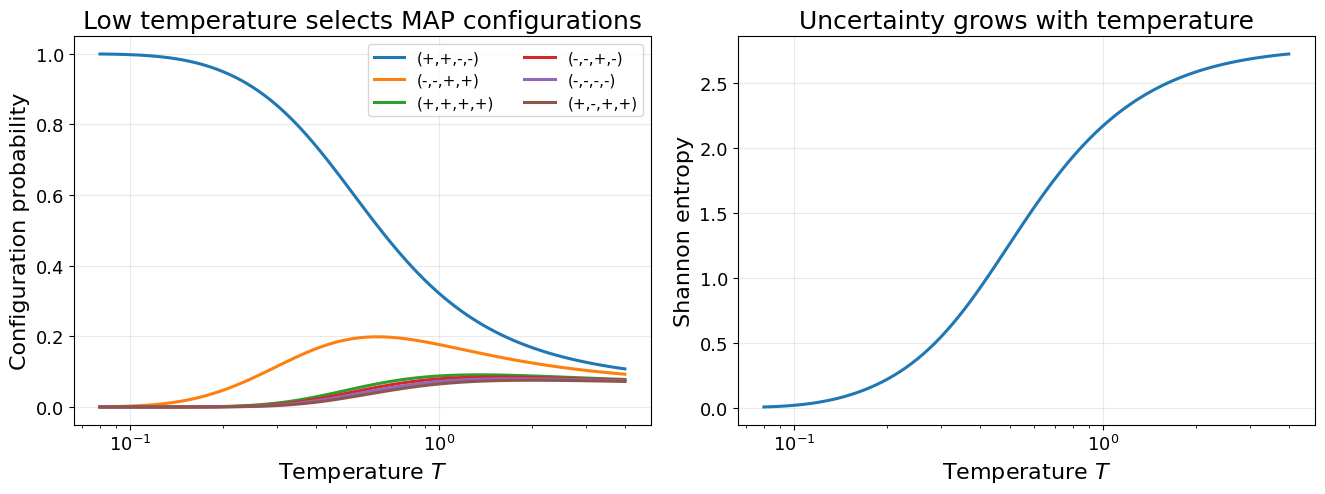

In [3]:
temperatures = np.geomspace(0.08, 4.0, 90)
top = order[:6]
curves = np.zeros((len(temperatures), len(top)))
entropies = []
for k, T in enumerate(temperatures):
    p, _, _ = distribution_at_temperature(T=T)
    curves[k] = p[top]
    entropies.append(-np.sum(p * np.log(p + 1e-300)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
for j, idx in enumerate(top):
    axes[0].semilogx(temperatures, curves[:, j], label=label_state(STATES[idx]))
axes[0].set_xlabel("Temperature $T$")
axes[0].set_ylabel("Configuration probability")
axes[0].set_title("Low temperature selects MAP configurations")
axes[0].grid(alpha=0.28)
axes[0].legend(ncol=2, fontsize=11)

axes[1].semilogx(temperatures, entropies)
axes[1].set_xlabel("Temperature $T$")
axes[1].set_ylabel("Shannon entropy")
axes[1].set_title("Uncertainty grows with temperature")
axes[1].grid(alpha=0.28)
fig.tight_layout()
save_figure(fig, "ch04_01_map_temperature")
plt.show()

## 3. Conditioning as a restricted partition function

Suppose the fourth spin is observed to be $x_4=+1$. The posterior distribution is obtained by restricting the state space and renormalizing:

$$
p(\boldsymbol{x}_{1:3}\mid x_4=+1)
=\frac{\exp(-E(\boldsymbol{x}_{1:3},+1))}
{\sum_{\boldsymbol{z}_{1:3}}\exp(-E(\boldsymbol{z}_{1:3},+1))}.
$$

The observation propagates through the chain and changes marginals even for variables that are not directly adjacent to $x_4$.

,variable,E[x_i],E[x_i | x_4=+1]
0,x1,0.234742,0.003931
1,x2,0.075589,-0.280663
2,x3,-0.021268,0.694524
3,x4,-0.202962,1.000000


Saved: figs/ch04_01_conditioning_marginals.pdf
Saved: figs/ch04_01_conditioning_marginals.png


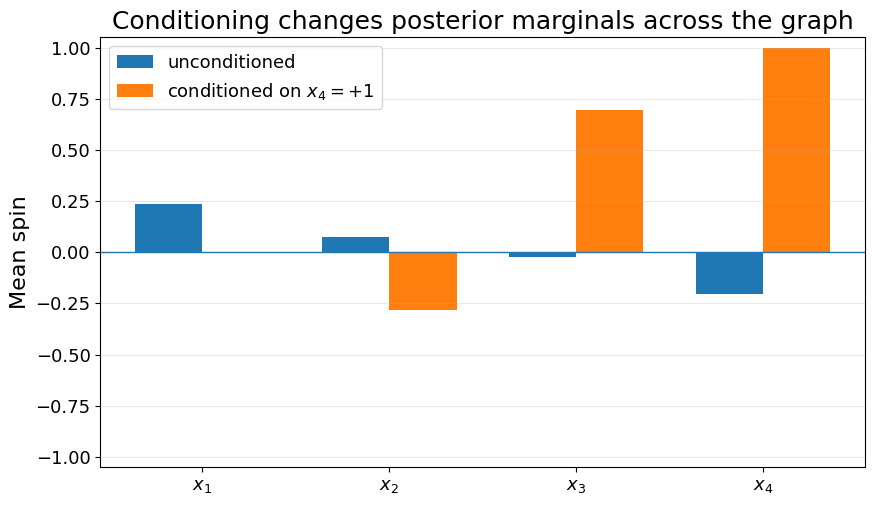

In [4]:
def singleton_means(states, probabilities):
    return probabilities @ states

unconditioned_means = singleton_means(STATES, p1)
mask = STATES[:, 3] == 1
p_conditioned = p1[mask] / p1[mask].sum()
conditioned_means = singleton_means(STATES[mask], p_conditioned)

summary = pd.DataFrame({
    "variable": [f"x{i}" for i in range(1, 5)],
    "E[x_i]": unconditioned_means,
    "E[x_i | x_4=+1]": conditioned_means,
})
display(summary)

indices = np.arange(4)
width = 0.36
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.bar(indices - width/2, unconditioned_means, width, label="unconditioned")
ax.bar(indices + width/2, conditioned_means, width, label=r"conditioned on $x_4=+1$")
ax.axhline(0, linewidth=1)
ax.set_xticks(indices, [rf"$x_{i}$" for i in range(1, 5)])
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel("Mean spin")
ax.set_title("Conditioning changes posterior marginals across the graph")
ax.legend()
ax.grid(axis="y", alpha=0.28)
fig.tight_layout()
save_figure(fig, "ch04_01_conditioning_marginals")
plt.show()

## 4. A graphical view of evidence

The graph is unchanged by conditioning; only the factor attached to the observed variable is replaced by a hard evidence factor. Dark nodes use white labels so the figure remains legible in print and on screen.

Saved: figs/ch04_01_conditioned_factor_graph.pdf
Saved: figs/ch04_01_conditioned_factor_graph.png


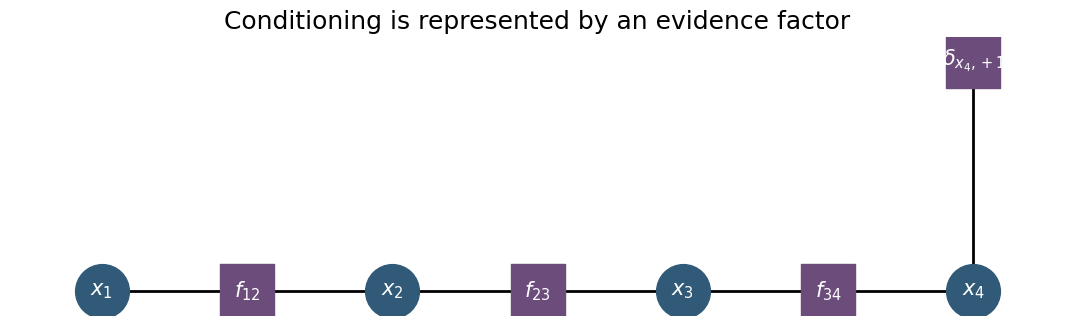

In [5]:
G = nx.Graph()
variables = [f"x{i}" for i in range(1, 5)]
factors = ["f12", "f23", "f34", "e4"]
G.add_nodes_from(variables, kind="variable")
G.add_nodes_from(factors, kind="factor")
G.add_edges_from([
    ("x1", "f12"), ("x2", "f12"),
    ("x2", "f23"), ("x3", "f23"),
    ("x3", "f34"), ("x4", "f34"),
    ("x4", "e4"),
])
pos = {
    "x1": (0,0), "f12": (1.1,0), "x2": (2.2,0), "f23": (3.3,0),
    "x3": (4.4,0), "f34": (5.5,0), "x4": (6.6,0), "e4": (6.6,1.25),
}
labels = {f"x{i}": rf"$x_{i}$" for i in range(1,5)}
labels.update({"f12":r"$f_{12}$", "f23":r"$f_{23}$", "f34":r"$f_{34}$", "e4":r"$\delta_{x_4,+1}$"})

fig, ax = plt.subplots(figsize=(11, 3.5))
nx.draw_networkx_edges(G, pos, width=2.0, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=variables, node_color=DARK_NODE, node_size=1500, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=factors, node_color=FACTOR_NODE, node_shape="s", node_size=1500, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=15, ax=ax)
ax.set_title("Conditioning is represented by an evidence factor")
ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch04_01_conditioned_factor_graph")
plt.show()

## Exercises

1. Condition on $x_1=-1$ instead of $x_4=+1$. Compare how the influence propagates through the chain.
2. Reverse the sign of $J_2$. Identify the MAP state and determine whether conditioning on $x_4=+1$ reinforces or competes with the central coupling.
3. Create a model with two exactly degenerate MAP configurations. Verify numerically that the low-temperature distribution approaches the uniform distribution on the MAP set.
4. Replace hard evidence by a noisy observation factor and study the continuous transition between no evidence and hard clamping.